In [28]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os # Added for path checking

# Set display options
pd.set_option('display.max_colwidth', 200)

In [29]:
# Define dataset file paths (MAKE SURE THESE ARE CORRECT FOR YOUR SYSTEM)
file_paths = {
    'CyNER': '/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/datasets/CyNER.txt',
    'DNRTI': '/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/datasets/DNRTI.txt',
    'APTNER': '/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/datasets/APTNER_full.txt',
    'Attacker': '/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/datasets/attacker.txt'
}

In [30]:
# --- Data Loading and Cleaning Function ---
def clean_conll_file(file_path, dataset_name, convert_bioes=False):
    """
    Cleans CoNLL-like file, optionally converts BIOES to BIO,
    handles known non-standard tags, and malformed lines.
    Returns a pandas DataFrame.
    """
    cleaned_data = []
    problematic_lines_log = [] # Keep track of issues for reporting
    current_sentence_id = 0
    line_number = 0
    in_sentence = False

    # Pattern for expected *standard* tags (O, or StartsWith B-/I-/E-/S- followed by Type)
    # Allows alphanumeric, hyphen, underscore in type
    expected_tag_pattern = re.compile(r"^(O|[BIESI]-[\w\-\.]+)$") # Added dot for filenames etc.

    # Known non-standard tags for specific datasets that need special handling
    known_non_standard_tags = {
        'APTNER': {'PROT'}
        # Add other dataset-specific exceptions if needed: 'DatasetName': {'TAG1', 'TAG2'}
    }
    non_standard_tags_for_this_dataset = known_non_standard_tags.get(dataset_name, set())

    print(f"Processing {dataset_name} from {file_path}...")

    if not os.path.exists(file_path):
        print(f"ERROR: File not found at {file_path}. Skipping {dataset_name}.")
        return pd.DataFrame(columns=['Word', 'Tag', 'Sentence_ID']) # Return empty DataFrame

    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                line_number += 1
                line = line.strip()

                if not line: # Blank line potentially indicates end of sentence
                    if in_sentence: # Only increment ID if we were actually in a sentence
                        current_sentence_id += 1
                        in_sentence = False
                    continue # Skip the blank line itself

                in_sentence = True # Mark that we are processing words in a sentence
                parts = line.split()

                # --- Handle Malformed Lines ---
                if len(parts) < 2:
                    warning_msg = f"Line {line_number}: Skipping malformed line - Not enough parts: '{line}'"
                    # Decide whether to log just the message or also the line number/content
                    problematic_lines_log.append((line_number, "Not enough parts", line))
                    print(f"WARNING: {warning_msg}")
                    continue # Skip processing this line further

                # Assume last part is the tag, rest is the word/token
                # Handle cases where word might contain spaces (though less common in CoNLL)
                original_tag = parts[-1]
                word = ' '.join(parts[:-1])
                final_tag = original_tag # Initialize final_tag for modification

                # --- Handle Obvious Invalid Original Tags (words mistakenly tagged) ---
                # Add more common words if needed, checking context is important
                if original_tag.lower() in ['also', 'as', 'is', 'in', 'on', 'at', 'the', 'a', 'an']:
                    # Check if the *previous* part looks like a valid tag - indicates parse error
                    possible_real_tag = parts[-2] if len(parts) > 2 else None
                    if possible_real_tag and expected_tag_pattern.match(possible_real_tag):
                        warning_msg = f"Line {line_number}: Likely parsing error. Found word '{original_tag}' as tag. Previous part '{possible_real_tag}' looks like tag. Reconstructing. Line: '{line}'"
                        # Attempt reconstruction (may need refinement based on data)
                        final_tag = possible_real_tag # Use the likely intended tag
                        word = ' '.join(parts[:-2])   # Adjust word parts
                        problematic_lines_log.append((line_number, f"Likely parse error, assigned '{final_tag}'", line))
                        print(f"WARNING: {warning_msg}")
                    else:
                        # Treat as untagged word if previous part isn't a tag
                        warning_msg = f"Line {line_number}: Found common word '{original_tag}' as tag. Assuming 'O' tag. Line: '{line}'"
                        word = ' '.join(parts) # Assume original_tag was part of the word
                        final_tag = 'O'
                        problematic_lines_log.append((line_number, f"Common word as tag, assigned 'O'", line))
                        print(f"WARNING: {warning_msg}")

                # --- Handle Known Non-Standard Tags (e.g., PROT) ---
                elif original_tag in non_standard_tags_for_this_dataset:
                    # Apply specific mapping for this dataset if convert_bioes is active
                    if convert_bioes:
                        # Convert known tags directly to B- prefix format
                        final_tag = 'B-' + original_tag
                        # Log this action if needed for debugging
                        # print(f"INFO: Line {line_number}: Mapping non-standard tag '{original_tag}' to '{final_tag}'.")
                    # If convert_bioes is False, final_tag remains original_tag
                    # Log that we encountered it
                    problematic_lines_log.append((line_number, f"Encountered known non-standard tag '{original_tag}'", line))


                # --- Apply Standard BIOES -> BIO Conversion ---
                # This runs *after* handling specific exceptions above if convert_bioes is True
                elif convert_bioes:
                    if original_tag.startswith('S-'):
                        final_tag = 'B-' + original_tag[2:]
                    elif original_tag.startswith('E-'):
                        final_tag = 'I-' + original_tag[2:]
                    # B-, I-, O tags were already handled by initializing final_tag = original_tag

                # --- Final Validation: Ensure the resulting tag is BIO compliant ---
                # Checks if tag is O, B-*, or I-*
                is_final_bio_compliant = (final_tag == 'O' or (final_tag.startswith('B-') and len(final_tag) > 2) or (final_tag.startswith('I-') and len(final_tag) > 2))

                if not is_final_bio_compliant:
                    # If after all conversions/handling, it's still not BIO, log and force 'O'
                    warning_msg = f"Line {line_number}: Final tag '{final_tag}' is non-BIO compliant after processing. Forcing 'O'. Original: '{original_tag}'. Line: '{line}'"
                    problematic_lines_log.append((line_number, f"Non-BIO final tag '{final_tag}', forced 'O'", line))
                    print(f"WARNING: {warning_msg}")
                    final_tag = 'O' # Force compliance

                # Append the cleaned/processed data
                cleaned_data.append([str(word), final_tag, current_sentence_id])

    except Exception as e:
        print(f"ERROR reading or processing file {file_path}: {e}")
        return pd.DataFrame(columns=['Word', 'Tag', 'Sentence_ID']) # Return empty DataFrame on error


    df = pd.DataFrame(cleaned_data, columns=['Word', 'Tag', 'Sentence_ID'])
    # Ensure Word column is string type to preserve special words like '0'
    df['Word'] = df['Word'].astype(str)
    print(f"Finished processing {dataset_name}. Found {current_sentence_id + 1} sentences.")

    # --- Report Issues Found During Processing ---
    if problematic_lines_log:
         print(f"\n--- ISSUES LOGGED for {dataset_name} ---")
         # Group issues by type for summary
         issue_counts = {}
         for _, issue_type, _ in problematic_lines_log:
             issue_counts[issue_type] = issue_counts.get(issue_type, 0) + 1
         for issue_type, count in issue_counts.items():
             print(f"  - Type: '{issue_type}', Count: {count}")
         # Optionally print detailed log (can be very long)
         # print("  Detailed Log:")
         # for ln, issue_type, content in problematic_lines_log:
         #     print(f"    Line {ln}: Type: '{issue_type}', Content: '{content}'")
         print(f"--- END ISSUES LOGGED for {dataset_name} ---\n")


    return df

# --- BIO Schema Checking Functions ---
def is_valid_bio_tag(tag):
    """Checks if a tag follows the B-<Type>, I-<Type>, or O format."""
    if tag == 'O':
        return True
    # Allow alphanumeric, hyphen, dot, potentially other chars in Type
    if tag.startswith('B-') and len(tag) > 2:
        return True
    if tag.startswith('I-') and len(tag) > 2:
        return True
    return False

def check_all_datasets_bio_schema(datasets_dict):
    """
    Iterates through datasets and checks if all tags conform to BIO schema.
    Reports any non-conforming tags found. Returns overall validity status.
    """
    print("\n--- Starting Final BIO Schema Check on Processed DataFrames ---")
    all_datasets_valid = True
    master_invalid_tags_summary = {}

    for name, df in datasets_dict.items():
        if df.empty:
            print(f"Checking dataset: '{name}'... SKIPPED (Empty DataFrame)")
            continue

        print(f"Checking dataset: '{name}'...")
        unique_tags = df['Tag'].unique()
        invalid_tags_in_df = []

        for tag in unique_tags:
            # Convert numpy types explicitly to string if needed, although pandas usually handles it
            tag_str = str(tag)
            if not is_valid_bio_tag(tag_str):
                invalid_tags_in_df.append(tag_str)
                all_datasets_valid = False

        if invalid_tags_in_df:
            # Store unique invalid tags, sorted
            master_invalid_tags_summary[name] = sorted(list(set(invalid_tags_in_df)))
            print(f"  WARNING: Found final non-BIO tags in '{name}': {master_invalid_tags_summary[name]}")
        else:
            print(f"  OK: All unique tags in '{name}' conform to BIO schema.")

    print("--- BIO Schema Check Complete ---")
    if all_datasets_valid:
        print("Result: All processed datasets appear to conform to the basic BIO tagging schema.")
    else:
        print("Result: Found datasets with non-conforming final BIO tags (see warnings above).")
        print("\nSummary of Non-BIO Tags Found in Final DataFrames:")
        for name, tags in master_invalid_tags_summary.items():
            print(f"  Dataset: {name}, Invalid Final Tags: {tags}")

    return all_datasets_valid

In [31]:
# 1. Load and Clean all datasets
datasets = {}
print("--- Loading and Cleaning Datasets ---")
for name, path in file_paths.items():
    # Determine if BIOES conversion should be applied
    apply_bioes_conversion = (name == 'APTNER') # Add other names if needed
    datasets[name] = clean_conll_file(
        file_path=path,
        dataset_name=name,
        convert_bioes=apply_bioes_conversion
    )

--- Loading and Cleaning Datasets ---
Processing CyNER from /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/datasets/CyNER.txt...
Finished processing CyNER. Found 4372 sentences.
Processing DNRTI from /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/datasets/DNRTI.txt...
Finished processing DNRTI. Found 6582 sentences.

--- ISSUES LOGGED for DNRTI ---
  - Type: 'Not enough parts', Count: 202
--- END ISSUES LOGGED for DNRTI ---

Processing APTNER from /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/datasets/APTNER_full.txt...
Finished processing APTNER. Found 10043 sentences.

--- ISSUES LOGGED for APTNER ---
  - Type: 'Encountered known non-standard tag 'PROT'', Count: 12
  - Type: 'Not enough parts', Count: 166
--- END ISSUES LOGGED for APTNER ---

Processing Attacker from /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/datasets/att

In [32]:
# 2. Perform the Final BIO Schema Check
check_result = check_all_datasets_bio_schema(datasets)

# 3. Optional: Display sample data or further analysis
if check_result:
    print("\n--- Sample Processed Data (First 5 rows per dataset) ---")
    for name, df in datasets.items():
        if not df.empty:
            print(f"\nDataset: {name}")
            print(df.head())
        else:
            print(f"\nDataset: {name} is empty.")
else:
    print("\nReview warnings and logs above to fix issues before proceeding.")


--- Starting Final BIO Schema Check on Processed DataFrames ---
Checking dataset: 'CyNER'...
  OK: All unique tags in 'CyNER' conform to BIO schema.
Checking dataset: 'DNRTI'...
  OK: All unique tags in 'DNRTI' conform to BIO schema.
Checking dataset: 'APTNER'...
  OK: All unique tags in 'APTNER' conform to BIO schema.
Checking dataset: 'Attacker'...
  OK: All unique tags in 'Attacker' conform to BIO schema.
--- BIO Schema Check Complete ---
Result: All processed datasets appear to conform to the basic BIO tagging schema.

--- Sample Processed Data (First 5 rows per dataset) ---

Dataset: CyNER
      Word        Tag  Sentence_ID
0    Super  B-Malware            0
1    Mario  I-Malware            0
2      Run  I-Malware            0
3  Malware  I-Malware            0
4        #          O            0

Dataset: DNRTI
        Word        Tag  Sentence_ID
0        The          O            0
1  admin@338  B-HackOrg            0
2        has          O            0
3    largely          O

In [33]:
def analyze_dataset(df, name):
    """Analyzes dataset statistics and entity distribution."""
    total_tokens = len(df)
    total_entities = len(df[df['Tag'] != 'O'])
    unique_tags = df['Tag'].nunique()
    entity_types = sorted(set(tag.split('-')[1] for tag in df['Tag'].unique() if tag != 'O' and '-' in tag))
    tag_distribution = df['Tag'].value_counts()

    print(f"=== {name} Dataset ===")
    print(f"Total Tokens: {total_tokens}")
    print(f"Total Entities: {total_entities}")
    print(f"Unique Entity Types: {len(entity_types)}")
    print(f"Entity Types: {entity_types}")
    print(tag_distribution.head(10))

    return {
        'Dataset': name,
        'Tokens': total_tokens,
        'Entities': total_entities,
        'Unique_Tags': unique_tags,
        'Entity_Types': entity_types,
        'Tag_Distribution': tag_distribution
    }

# Run analysis
stats = {name: analyze_dataset(df, name) for name, df in datasets.items()}

=== CyNER Dataset ===
Total Tokens: 106991
Total Entities: 7591
Unique Entity Types: 5
Entity Types: ['Indicator', 'Malware', 'Organization', 'System', 'Vulnerability']
Tag
O                  99400
I-Indicator         1816
B-Indicator         1490
B-System            1267
B-Malware           1199
I-System             696
B-Organization       507
I-Malware            251
I-Organization       248
B-Vulnerability       67
Name: count, dtype: int64
=== DNRTI Dataset ===
Total Tokens: 175679
Total Entities: 36882
Unique Entity Types: 12
Entity Types: ['Area', 'Exp', 'Features', 'HackOrg', 'OffAct', 'Org', 'Purp', 'SamFile', 'SecTeam', 'Time', 'Tool', 'Way']
Tag
O            138797
B-HackOrg      4213
B-Tool         3073
B-Org          2922
B-Area         2529
I-Org          1739
I-Tool         1703
B-SamFile      1698
B-Time         1678
B-OffAct       1665
Name: count, dtype: int64
=== APTNER Dataset ===
Total Tokens: 260290
Total Entities: 39703
Unique Entity Types: 23
Entity Types: ['ACT

In [35]:
# Extract entity types and their counts from CyNER
cyner_entity_counts = {}
for tag in datasets['CyNER']['Tag'].unique():
    if tag != 'O':
        entity_type = tag.split('-')[1] if '-' in tag else tag
        count = len(datasets['CyNER'][datasets['CyNER']['Tag'] == tag])
        if entity_type in cyner_entity_counts:
            cyner_entity_counts[entity_type] += count
        else:
            cyner_entity_counts[entity_type] = count

# Sort by count
sorted_cyner_entities = sorted(cyner_entity_counts.items(), key=lambda x: x[1], reverse=True)

# Get sample entities for each type
print("\nSample entities for each type:")
for entity_type, _ in sorted_cyner_entities:
    sample_indices = datasets['CyNER'][datasets['CyNER']['Tag'] == f"B-{entity_type}"].index[:6]
    samples = []
    
    for idx in sample_indices:
        # Get the full entity (B-X and all following I-X)
        entity_words = [datasets['CyNER'].loc[idx, 'Word']]
        i = idx + 1
        while i < len(datasets['CyNER']) and datasets['CyNER'].loc[i, 'Tag'] == f"I-{entity_type}":
            entity_words.append(datasets['CyNER'].loc[i, 'Word'])
            i += 1
        samples.append(" ".join(entity_words))
    
    print(f"{entity_type}: {', '.join(samples[:6])}")


Sample entities for each type:
Indicator: net.droidjack.server, 69b4b32e4636f1981841cbbe3b927560, .amr, video.3gp, AndroidOS_XLoader.HRXD, hxxp : //apple-icloud [ . ] qwq-japan [ . ] com
System: Mario, Pokemon, Android, Super Mario Run, Android, Super Mario Run
Malware: Super Mario Run Malware, DroidJack RAT, Marcher, DroidJack RAT, DroidJack RAT, DroidJack
Organization: Proofpoint, Trend Micro, Apple, Twitter, Twitter, Twitter
Vulnerability: VROOT, CVE-2013-6282, Towelroot, CVE-2014-3153, arbitrary memory read ( CVE-2012-2825 ), heap buffer overflow ( CVE-2012-2871 )


In [36]:
# Final mapping dictionary from CyNER to STIX entities
entity_cyner_stix_mapping_final = {
   # Malware entities
   'B-Malware': 'B-Malware',
   'I-Malware': 'I-Malware',

   # System entities -> Software
   'B-System': 'B-Software',
   'I-System': 'I-Software',

   # Organization entities -> Identity (Non-Actor)
   'B-Organization': 'B-Identity',
   'I-Organization': 'I-Identity',

   # Indicator entities
   'B-Indicator': 'B-Indicator',
   'I-Indicator': 'I-Indicator',

   # Vulnerability entities
   'B-Vulnerability': 'B-Vulnerability',
   'I-Vulnerability': 'I-Vulnerability'
}

In [37]:
# Extract entity types and their counts from DNRTI
dnrti_entity_counts = {}
for tag in datasets['DNRTI']['Tag'].unique():
    if tag != 'O':
        entity_type = tag.split('-')[1] if '-' in tag else tag
        count = len(datasets['DNRTI'][datasets['DNRTI']['Tag'] == tag])
        if entity_type in dnrti_entity_counts:
            dnrti_entity_counts[entity_type] += count
        else:
            dnrti_entity_counts[entity_type] = count

# Sort by count
sorted_dnrti_entities = sorted(dnrti_entity_counts.items(), key=lambda x: x[1], reverse=True)

# Get sample entities for each type
print("\nSample entities for each type in DNRTI:")
for entity_type, _ in sorted_dnrti_entities:
    sample_indices = datasets['DNRTI'][datasets['DNRTI']['Tag'] == f"B-{entity_type}"].index[:6]
    samples = []
    
    for idx in sample_indices:
        # Get the full entity (B-X and all following I-X)
        entity_words = [datasets['DNRTI'].loc[idx, 'Word']]
        i = idx + 1
        while i < len(datasets['DNRTI']) and datasets['DNRTI'].loc[i, 'Tag'] == f"I-{entity_type}":
            entity_words.append(datasets['DNRTI'].loc[i, 'Word'])
            i += 1
        samples.append(" ".join(entity_words))
    
    print(f"{entity_type}: {', '.join(samples[:6])}")


Sample entities for each type in DNRTI:
HackOrg: admin@338, admin@338, cyber threat groups, admin@338, admin@338, threat actors
Tool: publicly available RATs, Poison Ivy, non-public backdoors, LOWBALL malware, BUBBLEWRAP, Backdoor.APT.FakeWinHTTPHelper
Org: organizations, financial , economic and trade policy, media companies, political and economic challenges, international media organizations, international media organizations
Area: Hong Kong, Hong Kong, China, China-based, Western, China
OffAct: activities, targeted attacks, targeted attacks, activities, spear-phishing campaign, attack
Time: August 2015, August 2015, August 2015, 2008, 2008, August 2013
Features: collect information, send POST requests, contain information, connect to a command and control, persistence functionality, persistence functionality
SamFile: upload.bat, Vietnam.exe, Vietnam.exe, malicious file, malicious file, decoy documents
Purp: steal information, intelligence-gathering, intelligence-gathering, intelli

In [38]:
entity_dnrti_stix_mapping_final = { # Renamed for clarity
   # Threat Actor
   'B-HackOrg': 'B-Threat-Actor',
   'I-HackOrg': 'I-Threat-Actor',

   # Identity (Legitimate Orgs/Sectors/Vendors)
   'B-Org': 'B-Identity',
   'I-Org': 'I-Identity',
   'B-SecTeam': 'B-Identity',
   'I-SecTeam': 'I-Identity',

   # Tool (Acknowledge limitation: May include malware names)
   'B-Tool': 'B-Tool',
   'I-Tool': 'I-Tool',

   # Malware (Mapping filenames/malicious files here)
   'B-SamFile': 'B-Malware', # Or B-File ? Decide based on downstream use
   'I-SamFile': 'I-Malware', # Or I-File ?

   # Location
   'B-Area': 'B-Location',
   'I-Area': 'I-Location',

   # Attack Pattern (Captures actions, ways)
   'B-OffAct': 'B-Attack-Pattern',
   'I-OffAct': 'I-Attack-Pattern',
   'B-Way': 'B-Attack-Pattern',
   'I-Way': 'I-Attack-Pattern',

   # Malware Analysis (Using the standard STIX SDO)
   'B-Features': 'B-Malware-Analysis',
   'I-Features': 'I-Malware-Analysis',

   # Vulnerability
   'B-Exp': 'B-Vulnerability',
   'I-Exp': 'I-Vulnerability',

   # Mapped to O (Still recommended for Time/Purp for NER)
   'B-Time': 'O',
   'I-Time': 'O',
   'B-Purp': 'O',
   'I-Purp': 'O',
}

In [39]:
# Extract entity types and their counts from APTNER
aptner_entity_counts = {}
for tag in datasets['APTNER']['Tag'].unique():
    if tag != 'O':
        entity_type = tag.split('-')[1] if '-' in tag else tag
        count = len(datasets['APTNER'][datasets['APTNER']['Tag'] == tag])
        if entity_type in aptner_entity_counts:
            aptner_entity_counts[entity_type] += count
        else:
            aptner_entity_counts[entity_type] = count

# Sort by count 
sorted_aptner_entities = sorted(aptner_entity_counts.items(), key=lambda x: x[1], reverse=True)
# Get sample entities for each type
print("\nSample entities for each type in APTNER:")
for entity_type, _ in sorted_aptner_entities:
    sample_indices = datasets['APTNER'][datasets['APTNER']['Tag'] == f"B-{entity_type}"].index[:6]
    samples = []
    
    for idx in sample_indices:
        # Get the full entity (B-X and all following I-X)
        entity_words = [datasets['APTNER'].loc[idx, 'Word']]
        i = idx + 1
        while i < len(datasets['APTNER']) and datasets['APTNER'].loc[i, 'Tag'] == f"I-{entity_type}":
            entity_words.append(datasets['APTNER'].loc[i, 'Word'])
            i += 1
        samples.append(" ".join(entity_words))
    
    print(f"{entity_type}: {', '.join(samples[:6])}")


Sample entities for each type in APTNER:
IDTY: Ben-Gurion University, Ben-Gurion University, Microsoft, medical organizations, education organizations, Iranian government
APT: fileless attack, Glimpse, OilRig S-APT/APT34, Chafer, Chafer, Chafer
MAL: OilRig, Helminth, Trojan, Helminth, OilRig, OilRig
TOOL: email, Microsoft Word, Word, Juniper Networks VPN, Excel, Word
LOC: Israeli, Hebrew, Israel, Iranian, Israeli, Iranian
TIME: April 19-24 , 2017, April 24, April 26, April 11, January 2017, December 17 , 2018
ACT: DNS tunneling, builds a DNS query, executed whoami&ipconfig /all, phishing emails, Exfiltration, spear-phishing email
FILE: 13.doc, 558.doc, 1.doc, 3.doc, test4.hta, test5.hta
SECTEAM: Morphisec researchers, Israel National Cyber Event Readiness Team, CERT-IL, Marker, Israel ’s Cyber Security Research Center, Morphisec
VULNAME: zero-day, Remote Code Execution, Dirty COW, zero-day, zero-day, Flash Player zero-day
VULID: CVE-2017-0199, CVE-2018-20250, Exp.CVE-2018-20250, Exp.C

In [40]:
entity_aptner_stix_mapping_final = {
    # Primary STIX SDOs
    'B-APT': 'B-Threat-Actor',
    'I-APT': 'I-Threat-Actor',
    'B-MAL': 'B-Malware',
    'I-MAL': 'I-Malware',
    'B-TOOL': 'B-Tool',         # Keep as Tool, acknowledging some samples might be malware-related tools
    'I-TOOL': 'I-Tool',
    'B-SECTEAM': 'B-Identity',
    'I-SECTEAM': 'I-Identity',
    'B-IDTY': 'B-Identity',
    'I-IDTY': 'I-Identity',
    'B-LOC': 'B-Location',
    'I-LOC': 'I-Location',
    'B-ACT': 'B-Attack-Pattern',
    'I-ACT': 'I-Attack-Pattern',
    'B-VULNAME': 'B-Vulnerability', # Consolidate Vuln Name/ID
    'I-VULNAME': 'I-Vulnerability',
    'B-VULID': 'B-Vulnerability',
    'I-VULID': 'I-Vulnerability',

    # Cyber Observables (STIX SCOs)
    'B-FILE': 'B-File',
    'I-FILE': 'I-File',
    'B-DOM': 'B-Domain-Name',
    'I-DOM': 'I-Domain-Name',
    'B-OS': 'B-Software',       # OS fits Software
    'I-OS': 'I-Software',
    'B-PROT': 'B-Network-Traffic', # Protocol implies Network Traffic context
    'I-PROT': 'I-Network-Traffic',
    'B-SHA2': 'B-File', # Hash indicates a File
    'I-SHA2': 'I-File',
    'B-MD5': 'B-File',  # Hash indicates a File
    'I-MD5': 'I-File',
    'B-SHA1': 'B-File', # Hash indicates a File
    'I-SHA1': 'I-File',
    'B-IP': 'B-IPv4-Addr', # Specific Observable
    'I-IP': 'I-IPv4-Addr',
    'B-URL': 'B-URL',           # Specific Observable
    'I-URL': 'I-URL',
    'B-EMAIL': 'B-Email-Addr',  # Specific Observable
    'I-EMAIL': 'I-Email-Addr',

    # Mapped to O (Outside) for NER - Information often implicit or property-based in STIX
    'B-TIME': 'O',
    'I-TIME': 'O',
    'B-ENCR': 'O', # Encoding/Hashing Algorithm Names (often properties, not distinct entities)
    'I-ENCR': 'O',

    # Tags to map to 'O' (Outside/Ignore) due to rarity/unclarity/noise
    'S': 'O',
    'IDTYL': 'O',
}

In [41]:
# Extract entity types and their counts from attacker
attacker_entity_counts = {}
for tag in datasets['Attacker']['Tag'].unique():
    if tag != 'O':
        entity_type = tag.split('-')[1] if '-' in tag else tag
        count = len(datasets['Attacker'][datasets['Attacker']['Tag'] == tag])
        if entity_type in attacker_entity_counts:
            attacker_entity_counts[entity_type] += count
        else:
            attacker_entity_counts[entity_type] = count

# Sort by count
sorted_attacker_entities = sorted(attacker_entity_counts.items(), key=lambda x: x[1], reverse=True)

# Get sample entities for each type
print("\nSample entities for each type in Attacker:")
for entity_type, _ in sorted_attacker_entities:
    sample_indices = datasets['Attacker'][datasets['Attacker']['Tag'] == f"B-{entity_type}"].index[:6]
    samples = []
    
    for idx in sample_indices:
        # Get the full entity (B-X and all following I-X)
        entity_words = [datasets['Attacker'].loc[idx, 'Word']]
        i = idx + 1
        while i < len(datasets['Attacker']) and datasets['Attacker'].loc[i, 'Tag'] == f"I-{entity_type}":
            entity_words.append(datasets['Attacker'].loc[i, 'Word'])
            i += 1
        samples.append(" ".join(entity_words))
    
    print(f"{entity_type}: {', '.join(samples[:6])}")


Sample entities for each type in Attacker:
ATTACK_PATTERN: bypasses URL rewrite mitigations for the endpoint, phishing, secondary payloads, This sample works in tandem with PIEHOP , which sets up the execution, OWASSRF, The code hunted for several security products to evade
COURSE_OF_ACTION: respond and block threats in realtime, do n't click on the links, do n’t click on any attachments, Organizations should apply the November 8 , 2022 patches for Exchange to prevent exploitation, URL rewrite mitigations, dual controls need to be put in place
OBSERVED_DATA: The IP range for “ PIG GOD ” is 43[.]255[.]188.0/22, 66[.]to, " pack\scil\s1.txt " is likely a file containing SCIL commands the attackers executed in MicroSCADA, emerged as the second - largest ransomware target, enduring close to 200 ransomware attacks, enumerate through directories and files in directories starting from “ A : ” to “ Z : ” drives
MALWARE_ANALYSIS: this algorithm deployed by other groups, either as a standalone e

In [44]:
entity_attacker_stix_mapping_final = {
   # Direct STIX SDO/SCO Mappings
   'B-ATTACK_PATTERN': 'B-Attack-Pattern',
   'I-ATTACK_PATTERN': 'I-Attack-Pattern',
   'B-COURSE_OF_ACTION': 'B-Course-of-Action',
   'I-COURSE_OF_ACTION': 'I-Course-of-Action',
   'B-OBSERVED_DATA': 'B-Observed-Data',
   'I-OBSERVED_DATA': 'I-Observed-Data',
   'B-MALWARE_ANALYSIS': 'B-Malware-Analysis',
   'I-MALWARE_ANALYSIS': 'I-Malware-Analysis',
   'B-INDICATOR': 'B-Indicator',
   'I-INDICATOR': 'I-Indicator',
   'B-THREAT_ACTOR': 'B-Threat-Actor',
   'I-THREAT_ACTOR': 'I-Threat-Actor',
   'B-INFRASTRUCTURE': 'B-Infrastructure',
   'I-INFRASTRUCTURE': 'I-Infrastructure',
   'B-VULNERABILITY': 'B-Vulnerability',
   'I-VULNERABILITY': 'I-Vulnerability',
   'B-MALWARE': 'B-Malware',
   'I-MALWARE': 'I-Malware',
   'B-INTRUSION_SET': 'B-Intrusion-Set',
   'I-INTRUSION_SET': 'I-Intrusion-Set',
   'B-CAMPAIGN': 'B-Campaign',
   'I-CAMPAIGN': 'I-Campaign',
   'B-LOCATION': 'B-Location',
   'I-LOCATION': 'I-Location',

   # Consolidated STIX Mappings
   'B-VICTIM_IDENTITY': 'B-Identity', # Consolidate into Identity
   'I-VICTIM_IDENTITY': 'I-Identity',
   'B-GENERAL_IDENTITY': 'B-Identity',
   'I-GENERAL_IDENTITY': 'I-Identity',
   'B-ATTACK_TOOL': 'B-Tool',         # Consolidate into Tool
   'I-ATTACK_TOOL': 'I-Tool',
   'B-GENERAL_TOOL': 'B-Tool',
   'I-GENERAL_TOOL': 'I-Tool',

   # Mapped to O (Outside) - Non-standard STIX concepts for NER
   'B-IMPACT': 'O',
   'I-IMPACT': 'O',
   'B-ATTACK_MOTIVATION': 'O',
   'I-ATTACK_MOTIVATION': 'O',
   'B-ATTACK_RESOURCE_LEVEL': 'O',
   'I-ATTACK_RESOURCE_LEVEL': 'O',
   'B-ATTACK_SOPHISTICATION_LEVEL': 'O',
   'I-ATTACK_SOPHISTICATION_LEVEL': 'O'
}

In [45]:
def create_unified_stix_dataset(datasets, mapping_dicts):
   """
   Creates a unified dataset with all original datasets mapped to STIX format.
   
   Args:
       datasets: Dictionary of dataframes with dataset name as key
       mapping_dicts: Dictionary of mapping dictionaries with dataset name as key
   
   Returns:
       Dictionary of dataframes with original and mapped STIX tags
   """
   stix_datasets = {}
   
   for dataset_name, df in datasets.items():
       # Select the appropriate mapping dictionary
       if dataset_name == 'APTNER':
           mapping_dict = entity_aptner_stix_mapping_final
       elif dataset_name == 'CyNER':
           mapping_dict = entity_cyner_stix_mapping_final
       elif dataset_name == 'DNRTI':
           mapping_dict = entity_dnrti_stix_mapping_final
       elif dataset_name == 'Attacker':
           mapping_dict = entity_attacker_stix_mapping_final
       else:
           # Default to empty mapping for unmapped datasets
           mapping_dict = {}
       
       # Create a copy of the original dataframe
       stix_df = df.copy()
       
       # Add a new column for STIX tags
       stix_df['STIX_Tag'] = stix_df['Tag'].map(
           lambda x: mapping_dict.get(x, 'O') if x != 'O' else 'O'
       )
       
       # Add dataset origin column
       stix_df['Source'] = dataset_name
       
       stix_datasets[dataset_name] = stix_df
   
   return stix_datasets

# Create all STIX-mapped datasets
stix_datasets = create_unified_stix_dataset(datasets, {
   'APTNER': entity_aptner_stix_mapping_final,
   'CyNER': entity_cyner_stix_mapping_final,
   'DNRTI': entity_dnrti_stix_mapping_final,
   'Attacker': entity_attacker_stix_mapping_final
})

# Example: Combine all datasets into a single dataframe if needed
combined_stix_df = pd.concat(stix_datasets.values(), ignore_index=True)

In [46]:
combined_stix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609922 entries, 0 to 609921
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Word         609922 non-null  object
 1   Tag          609922 non-null  object
 2   Sentence_ID  609922 non-null  int64 
 3   STIX_Tag     609922 non-null  object
 4   Source       609922 non-null  object
dtypes: int64(1), object(4)
memory usage: 23.3+ MB


In [47]:
stix_datasets['CyNER'].head(25)

,Word,Tag,Sentence_ID,STIX_Tag,Source
0,Super,B-Malware,0,B-Malware,CyNER
1,Mario,I-Malware,0,I-Malware,CyNER
2,Run,I-Malware,0,I-Malware,CyNER
3,Malware,I-Malware,0,I-Malware,CyNER
4,#,O,0,O,CyNER
5,2,O,0,O,CyNER
6,–,O,0,O,CyNER
7,DroidJack,B-Malware,0,B-Malware,CyNER
8,RAT,I-Malware,0,I-Malware,CyNER
9,Gamers,O,0,O,CyNER


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assume 'combined_stix_df' is your final DataFrame ---
# It should have columns like: 'Word', 'Tag', 'Sentence_ID', 'STIX_Tag', 'Source'

# --- Ensure DataFrame exists and is not empty ---
if 'combined_stix_df' not in locals() or combined_stix_df.empty:
    print("Error: combined_stix_df does not exist or is empty. Load your data first.")
    # exit() # Or handle appropriately

# --- 1. Overall Corpus Size ---
print("--- 1. Overall Corpus Size ---")
total_tokens = len(combined_stix_df)
total_sentences = combined_stix_df['Sentence_ID'].nunique()
# Assuming Sentence_ID groups sentences from different original documents.
# If you have a separate Document_ID column, use that:
# total_documents = combined_stix_df['Document_ID'].nunique()

print(f"Total Tokens: {total_tokens}")
print(f"Total Sentences: {total_sentences}")
# print(f"Total Documents: {total_documents}") # If applicable

# --- 2. Annotation Density ---
print("\n--- 2. Annotation Density ---")
# Filter out 'O' tags to count only actual entities
entities_df = combined_stix_df[combined_stix_df['STIX_Tag'] != 'O'].copy()
total_annotated_entities = len(entities_df)
percentage_annotated = (total_annotated_entities / total_tokens) * 100 if total_tokens > 0 else 0

print(f"Total Annotated Entity Tokens: {total_annotated_entities}")
print(f"Percentage of Annotated Tokens: {percentage_annotated:.2f}%")

# --- 3. Unified Schema Characteristics ---
print("\n--- 3. Unified Schema Characteristics ---")
# Extract base entity type (remove B-/I- prefix)
def get_base_tag(tag):
    if tag == 'O' or '-' not in tag:
        return 'O' # Treat non-BIO tags as O for type counting
    return tag.split('-', 1)[1] # Split only on the first hyphen

entities_df['Base_STIX_Tag'] = entities_df['STIX_Tag'].apply(get_base_tag)
unique_stix_entity_types = sorted(entities_df['Base_STIX_Tag'].unique())
num_unique_stix_types = len(unique_stix_entity_types)

print(f"Number of Unique STIX Entity Types (excluding O): {num_unique_stix_types}")
print(f"Unified STIX Entity Types: {unique_stix_entity_types}")

# --- 4. Entity Distribution ---
print("\n--- 4. Entity Distribution (Counts per STIX Type) ---")
# Count occurrences of each base STIX type
stix_type_distribution = entities_df['Base_STIX_Tag'].value_counts().reset_index()
stix_type_distribution.columns = ['STIX_Type', 'Count']
stix_type_distribution['Percentage'] = (stix_type_distribution['Count'] / total_annotated_entities) * 100 if total_annotated_entities > 0 else 0
stix_type_distribution = stix_type_distribution.sort_values(by='Count', ascending=False)

print("Distribution of Entities by STIX Type:")
# Display as a table (copy/paste friendly for LaTeX/Markdown)
print(stix_type_distribution.to_markdown(index=False))

# --- Visualization (Optional but Recommended) ---
try:
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Count', y='STIX_Type', data=stix_type_distribution, palette='viridis')
    plt.title('Distribution of Entities by Unified STIX Type in BEACON')
    plt.xlabel('Number of Mentions')
    plt.ylabel('STIX Entity Type')
    plt.tight_layout()
    # Save the figure
    plt.savefig('beacon_entity_distribution.png', dpi=300)
    plt.savefig('beacon_entity_distribution.pdf') # Save as PDF too
    print("\nSaved entity distribution plot to 'beacon_entity_distribution.png/pdf'")
    # plt.show() # Uncomment to display plot directly if running interactively
    plt.close() # Close plot to free memory
except Exception as e:
    print(f"\nWarning: Could not generate entity distribution plot. Error: {e}")


# --- 5. Source Contribution ---
print("\n--- 5. Source Contribution ---")
source_stats = []
total_source_entities_check = 0 # For verification

for source_name in combined_stix_df['Source'].unique():
    source_df = combined_stix_df[combined_stix_df['Source'] == source_name]
    source_tokens = len(source_df)
    source_entities = len(source_df[source_df['STIX_Tag'] != 'O'])
    total_source_entities_check += source_entities
    source_token_pct = (source_tokens / total_tokens) * 100 if total_tokens > 0 else 0
    source_entity_pct = (source_entities / total_annotated_entities) * 100 if total_annotated_entities > 0 else 0
    source_stats.append({
        'Source': source_name,
        'Token_Count': source_tokens,
        'Token_Percent': f"{source_token_pct:.2f}%",
        'Entity_Count': source_entities,
        'Entity_Percent': f"{source_entity_pct:.2f}%"
    })

source_contribution_df = pd.DataFrame(source_stats)
print("Contribution by Source Dataset:")
# Display as a table
print(source_contribution_df.to_markdown(index=False))

# Verification check
if total_source_entities_check != total_annotated_entities:
     print(f"Warning: Sum of entities per source ({total_source_entities_check}) does not match total annotated entities ({total_annotated_entities}). Check logic.")


# --- 5b. (Optional but Insightful) Distribution of STIX Types per Source ---
print("\n--- 5b. Distribution of STIX Types per Source (Counts) ---")
# Requires 'Base_STIX_Tag' column created earlier in entities_df
source_type_distribution = entities_df.groupby(['Source', 'Base_STIX_Tag']).size().unstack(fill_value=0)

# Add row totals (Entities per Source - should match previous calc)
source_type_distribution['Total_Entities_Source'] = source_type_distribution.sum(axis=1)
# Add column totals (Entities per STIX Type - should match previous calc)
source_type_distribution.loc['Total_Entities_Type'] = source_type_distribution.sum(axis=0)

print("Counts of each STIX Entity Type contributed by each Source:")
# Display as a table
print(source_type_distribution.to_markdown())


# --- 6. Vocabulary Size ---
print("\n--- 6. Vocabulary Size ---")
# Consider lowercasing for a potentially more meaningful vocab size,
# depending on whether your model is case-sensitive.
# vocab_size = combined_stix_df['Word'].str.lower().nunique()
vocab_size = combined_stix_df['Word'].nunique()
print(f"Total Unique Words/Tokens (Case-Sensitive): {vocab_size}")

# --- Prepare summary dictionary/dataframe for easy export ---
summary_stats = {
    "Total Tokens": total_tokens,
    "Total Sentences": total_sentences,
    "Total Annotated Entity Tokens": total_annotated_entities,
    "Percentage Annotated Tokens": percentage_annotated,
    "Number Unique STIX Types": num_unique_stix_types,
    "Unique STIX Types": unique_stix_entity_types,
    "Vocabulary Size": vocab_size
    # You can add the distribution dataframes here if needed
}
print("\n--- Summary Stats Dictionary ---")
print(summary_stats)

# You can now use the printed tables (formatted in Markdown) and the
# summary_stats dictionary to populate the tables and text in your paper.
# The plot 'beacon_entity_distribution.png/pdf' is also ready.

--- 1. Overall Corpus Size ---
Total Tokens: 609922
Total Sentences: 10042

--- 2. Annotation Density ---
Total Annotated Entity Tokens: 103248
Percentage of Annotated Tokens: 16.93%

--- 3. Unified Schema Characteristics ---
Number of Unique STIX Entity Types (excluding O): 21
Unified STIX Entity Types: ['Attack-Pattern', 'Campaign', 'Course-of-Action', 'Domain-Name', 'Email-Addr', 'File', 'IPv4-Addr', 'Identity', 'Indicator', 'Infrastructure', 'Intrusion-Set', 'Location', 'Malware', 'Malware-Analysis', 'Network-Traffic', 'Observed-Data', 'Software', 'Threat-Actor', 'Tool', 'URL', 'Vulnerability']

--- 4. Entity Distribution (Counts per STIX Type) ---
Distribution of Entities by STIX Type:
| STIX_Type        |   Count |   Percentage |
|:-----------------|--------:|-------------:|
| Identity         |   17451 |   16.902     |
| Attack-Pattern   |   17208 |   16.6667    |
| Threat-Actor     |   12151 |   11.7688    |
| Malware          |   10276 |    9.95274   |
| Tool             |   1

<ipython-input-48-c8f216b374d8>:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='STIX_Type', data=stix_type_distribution, palette='viridis')



Saved entity distribution plot to 'beacon_entity_distribution.png/pdf'

--- 5. Source Contribution ---
Contribution by Source Dataset:
| Source   |   Token_Count | Token_Percent   |   Entity_Count | Entity_Percent   |
|:---------|--------------:|:----------------|---------------:|:-----------------|
| CyNER    |        106991 | 17.54%          |           7591 | 7.35%            |
| DNRTI    |        175679 | 28.80%          |          31799 | 30.80%           |
| APTNER   |        260290 | 42.68%          |          35821 | 34.69%           |
| Attacker |         66962 | 10.98%          |          28037 | 27.16%           |

--- 5b. Distribution of STIX Types per Source (Counts) ---
Counts of each STIX Entity Type contributed by each Source:
| Source              |   Attack-Pattern |   Campaign |   Course-of-Action |   Domain-Name |   Email-Addr |   File |   IPv4-Addr |   Identity |   Indicator |   Infrastructure |   Intrusion-Set |   Location |   Malware |   Malware-Analysis |   Net

<ipython-input-53-b0858b764ce9>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


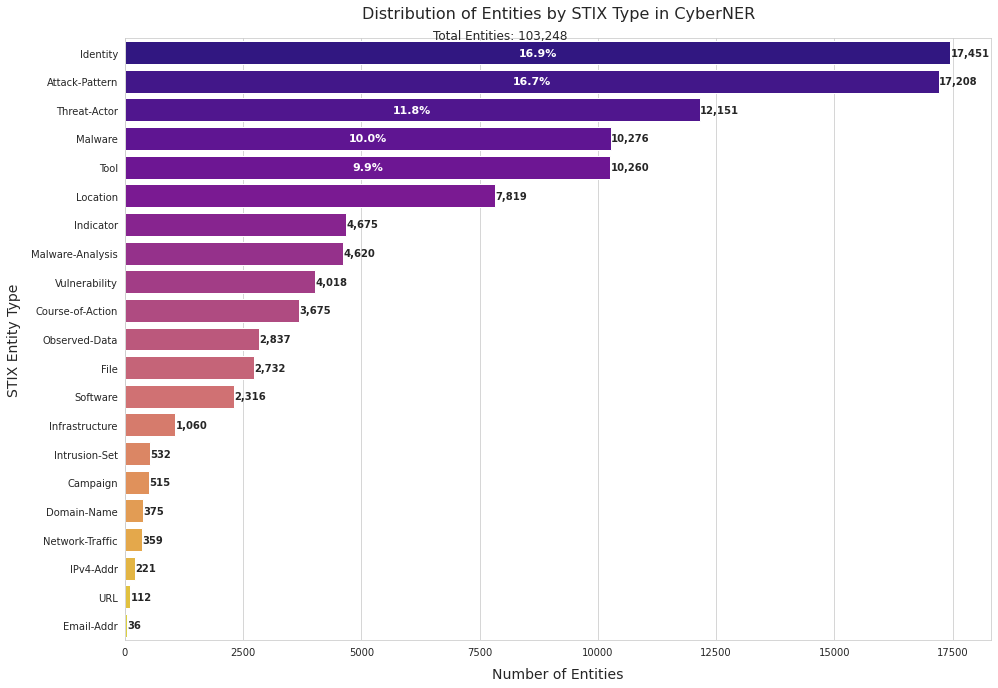

In [53]:
# --- Entity Distribution with Custom Colors --- 
try:     
    # Set the style     
    sns.set_style("whitegrid")     
    plt.figure(figsize=(14, 10))          
    
    # Option 1: Using a different built-in colormap     
    # Some good options: 'plasma', 'magma', 'inferno', 'cividis', 'rocket', 'mako'     
    colormap = 'plasma'  # You can change this to any matplotlib colormap          
    
    # Create the plot     
    ax = sns.barplot(         
        x='Count',          
        y='STIX_Type',          
        data=stix_type_distribution,         
        palette=colormap,         
        dodge=False     
    )          
    
    # Add value labels to each bar     
    for i, v in enumerate(stix_type_distribution['Count']):         
        ax.text(v + 5, i, f"{v:,}", va='center', fontweight='bold')     
    
    # Add percentage labels for only the first 5 rows
    top_5_indices = range(min(5, len(stix_type_distribution)))
    for i in top_5_indices:
        v = stix_type_distribution['Count'].iloc[i]
        p = stix_type_distribution['Percentage'].iloc[i]
        ax.text(v/2, i, f"{p:.1f}%", va='center', ha='center', 
                color='white', fontweight='bold', fontsize=11)
    
    # Customize the plot     
    plt.title('Distribution of Entities by STIX Type in BEACON', fontsize=16, pad=20)
    
    # Add total entities count as subtitle
    plt.suptitle(f'Total Entities: {total_annotated_entities:,}', 
                fontsize=12, y=0.92)
                
    plt.xlabel('Number of Entities', fontsize=14, labelpad=10)     
    plt.ylabel('STIX Entity Type', fontsize=14, labelpad=10)          
    
    plt.tight_layout()     
    plt.show()      
    
except Exception as e:     
    print(f"\nWarning: Could not generate entity distribution plot. Error: {e}")

In [54]:
combined_stix_df.to_csv('/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/dataset/beacon_stix_v1.csv', index=False)